In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-03-25 08:50:38.500819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774428638.788622      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774428638.861645      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774428639.476452      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774428639.476553      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774428639.476556      55 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/datasets/gitikapal/tweets/Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [5]:
print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [6]:
df = df[['text', 'sentiment']]
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [7]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

df[['sentiment', 'label']].head()

/tmp/ipykernel_55/481088959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = le.fit_transform(df['sentiment'])


,sentiment,label
0,neutral,1
1,negative,0
2,negative,0
3,negative,0
4,negative,0


In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

/tmp/ipykernel_55/1958439082.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['text'].apply(clean_text)


In [12]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=50)

y = df['label']

In [13]:
df.dropna(inplace=True)

/tmp/ipykernel_55/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=5000, output_dim=64, input_length=50))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(3, activation='softmax'))

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-03-25 08:59:29.181567: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4818 - loss: 0.9995 - val_accuracy: 0.6730 - val_loss: 0.7604
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7508 - loss: 0.6203 - val_accuracy: 0.6636 - val_loss: 0.8009
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8609 - loss: 0.3874 - val_accuracy: 0.6310 - val_loss: 0.9880
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9303 - loss: 0.2176 - val_accuracy: 0.6425 - val_loss: 1.1754
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9565 - loss: 0.1346 - val_accuracy: 0.6208 - val_loss: 1.3986


In [18]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=5000, output_dim=64, input_length=50))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5413 - loss: 0.9378 - val_accuracy: 0.7007 - val_loss: 0.7073
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7518 - loss: 0.6033 - val_accuracy: 0.7182 - val_loss: 0.6779
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7970 - loss: 0.5145 - val_accuracy: 0.7109 - val_loss: 0.6797
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8257 - loss: 0.4560 - val_accuracy: 0.7092 - val_loss: 0.7302
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8483 - loss: 0.4033 - val_accuracy: 0.7045 - val_loss: 0.7480


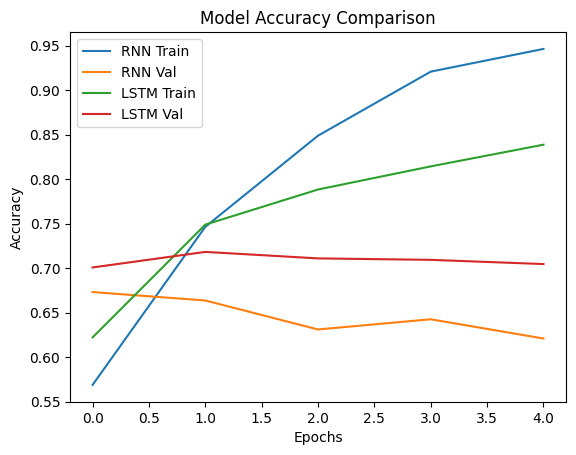

In [20]:
plt.figure()
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['RNN Train', 'RNN Val', 'LSTM Train', 'LSTM Val'])

plt.show()

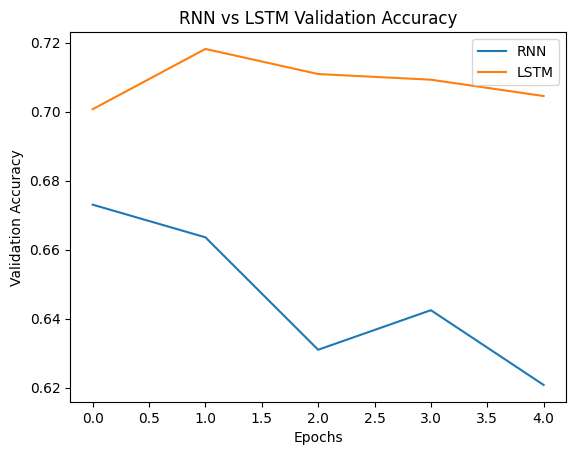

In [23]:
plt.figure()


plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')

plt.title("RNN vs LSTM Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

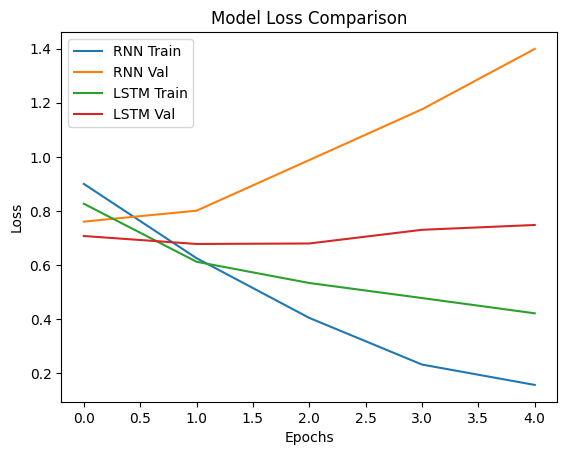

In [22]:
plt.figure()
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])

plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['RNN Train', 'RNN Val', 'LSTM Train', 'LSTM Val'])

plt.show()

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6277 - loss: 1.3787
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7055 - loss: 0.7556
RNN Accuracy: 0.6208151578903198
LSTM Accuracy: 0.704512357711792


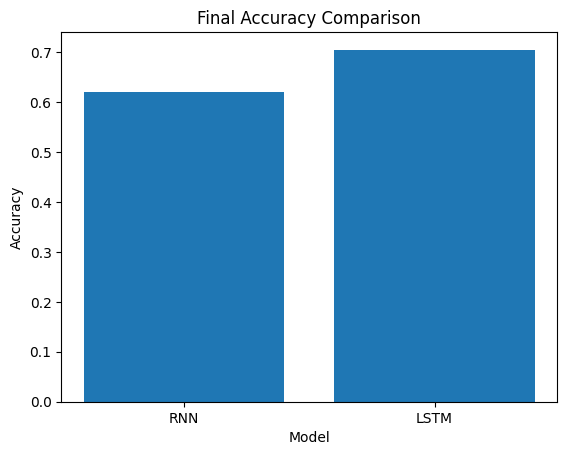

In [21]:
rnn_acc = rnn_model.evaluate(X_test, y_test)[1]
lstm_acc = lstm_model.evaluate(X_test, y_test)[1]

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)

models = ['RNN', 'LSTM']
accuracies = [rnn_acc, lstm_acc]

plt.figure()
plt.bar(models, accuracies)

plt.title('Final Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.show()